,n_outliers
luminosity_bin,
L < 42,123
42 < L < 43,290
43 < L < 44,420
44 < L < 45,731


,row_index,object_id,ID_COSMOS,COSMOS_ID0,luminosity_bin,log_stellar_mass_truth,recovered_logm,logm16,logm84,residual_log_ratio,errorbar_y_min,errorbar_y_max
0,47,030121.75-004920.4_782136_0.0001,782136,782136,L < 42,9.39808,8.344648,8.231902,8.574277,-1.053432,-1.166178,-0.823803
1,52,030555.41+002153.1_922277_0.0003,922277,922277,L < 42,10.75060,9.067817,8.184801,9.589618,-1.682783,-2.565799,-1.160982
2,89,034419.83+001250.6_945627_0.0001,945627,945627,L < 42,9.92763,8.462659,8.210879,8.827383,-1.464971,-1.716751,-1.100247
3,94,035110.04-011403.0_717776_0.0001,717776,717776,L < 42,9.54200,8.299384,8.014699,8.600554,-1.242616,-1.527301,-0.941446
4,101,064902.92+284710.4_782136_0.0001,782136,782136,L < 42,9.39808,7.709817,7.644020,7.794479,-1.688263,-1.754060,-1.603601
...,...,...,...,...,...,...,...,...,...,...,...,...
1559,13521,173050.72+315815.0_902651_0.03,902651,902651,44 < L < 45,10.54580,9.266712,7.757118,10.025188,-1.279088,-2.788682,-0.520612
1560,13525,173238.55+543232.5_621187_0.1,621187,621187,44 < L < 45,10.39080,8.823525,8.000510,9.648705,-1.567275,-2.390290,-0.742095
1561,13528,173239.82+613041.0_911911_0.3,911911,911911,44 < L < 45,10.33010,9.426511,8.301344,9.812444,-0.903589,-2.028756,-0.517656
1562,13532,173811.90+554846.2_622534_0.03,622534,622534,44 < L < 45,10.42450,9.565630,9.240017,9.865840,-0.858870,-1.184483,-0.558660


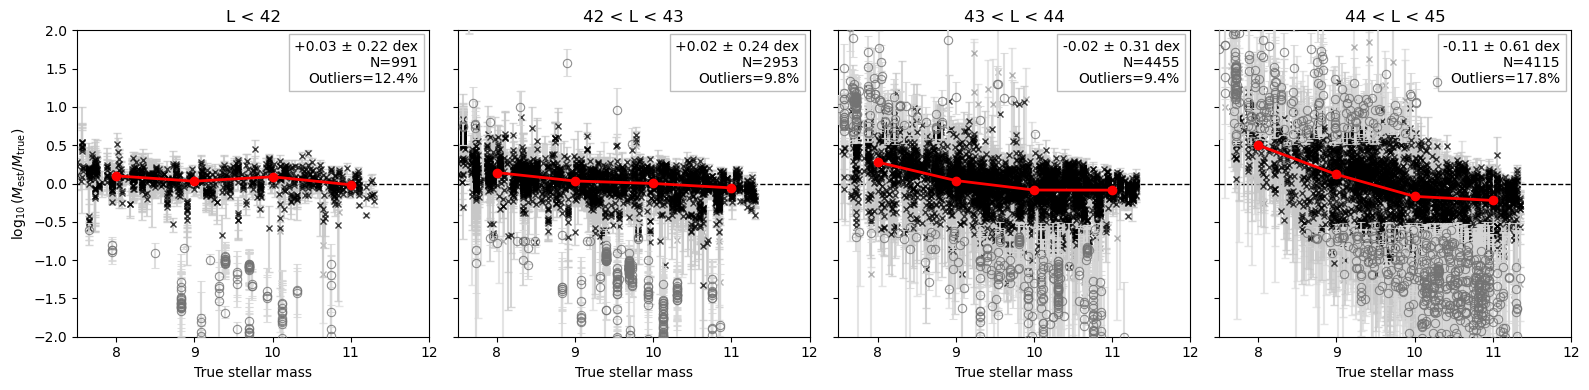

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CHOOSE THE DATA SOURCE HERE
# ============================================================
# This cell only reads an existing results table and makes the plot.
# It does not run any fitting.
notebook_dir = Path.cwd().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir

# Use an absolute path, a path relative to this notebook, a path relative to
# the project root, or an already-loaded pandas DataFrame.
data_source = project_root / "chimera_mass_retrieval_by_logLbol.csv"

# If your table uses different names, change these here.
columns = {
    "luminosity_bin": "luminosity_bin",
    "truth_logm": None,  # None auto-detects truth_logm or log_stellar_mass_truth
    "recovered_logm": "recovered_logm",
    "logm16": "logm16",
    "logm84": "logm84",
    "residual_log_ratio": "residual_log_ratio",
}

bin_order = ["L < 42", "42 < L < 43", "43 < L < 44", "44 < L < 45"]
mass_centers = np.array([8, 9, 10, 11])


def _resolve_path(source):
    source = Path(source).expanduser()
    candidates = [source]
    if not source.is_absolute():
        candidates.extend([notebook_dir / source, project_root / source])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    tried = "\n".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"Could not find data source. Tried:\n{tried}")


def load_mass_retrieval_data(source, **read_kwargs):
    if isinstance(source, pd.DataFrame):
        return source.copy()

    path = _resolve_path(source)
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path, **read_kwargs)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path, **read_kwargs)
    if suffix in {".pkl", ".pickle"}:
        return pd.read_pickle(path, **read_kwargs)

    raise ValueError(f"Unsupported data file type: {path.suffix}")


def _column_name(df, requested, fallbacks, label):
    names = [requested] if requested is not None else []
    names.extend(fallbacks)

    for name in names:
        if name in df.columns:
            return name

    raise KeyError(
        f"Could not find column for {label}. Tried {names}. "
        f"Available columns: {list(df.columns)}"
    )


def central_region_excluding_errorbar_mask(y, yerr_lower, yerr_upper):
    lower = y - yerr_lower
    upper = y + yerr_upper
    return (lower > 0.5) | (upper < -0.5)


def large_errorbar_mask(yerr_lower, yerr_upper, threshold=1.0):
    return (yerr_lower > threshold) | (yerr_upper > threshold)


def list_mass_retrieval_outliers(
    results_df,
    columns=columns,
    bin_order=bin_order,
    min_truth_logm=7.5,
):
    bin_col = _column_name(results_df, columns["luminosity_bin"], [], "luminosity_bin")
    truth_col = _column_name(
        results_df,
        columns["truth_logm"],
        ["truth_logm", "log_stellar_mass_truth"],
        "truth_logm",
    )
    recovered_col = _column_name(results_df, columns["recovered_logm"], [], "recovered_logm")
    logm16_col = _column_name(results_df, columns["logm16"], [], "logm16")
    logm84_col = _column_name(results_df, columns["logm84"], [], "logm84")
    id_cols = [col for col in ["object_id", "ID_COSMOS", "COSMOS_ID0"] if col in results_df.columns]

    residual_col = columns.get("residual_log_ratio")
    if residual_col not in results_df.columns:
        residual_col = None

    outlier_tables = []

    for label in bin_order:
        df = results_df[results_df[bin_col] == label].copy()
        if len(df) == 0:
            continue

        x = df[truth_col].to_numpy()
        recovered = df[recovered_col].to_numpy()
        y = df[residual_col].to_numpy() if residual_col else recovered - x
        yerr_lower = recovered - df[logm16_col].to_numpy()
        yerr_upper = df[logm84_col].to_numpy() - recovered

        keep = x >= min_truth_logm
        outlier = np.zeros(len(df), dtype=bool)
        outlier[keep] = central_region_excluding_errorbar_mask(
            y[keep], yerr_lower[keep], yerr_upper[keep]
        )

        if not np.any(outlier):
            continue

        outliers = df.loc[outlier, id_cols + [bin_col, truth_col, recovered_col, logm16_col, logm84_col]].copy()
        outliers["residual_log_ratio"] = y[outlier]
        outliers["errorbar_y_min"] = y[outlier] - yerr_lower[outlier]
        outliers["errorbar_y_max"] = y[outlier] + yerr_upper[outlier]
        outliers.index.name = "row_index"
        outlier_tables.append(outliers.reset_index())

    if not outlier_tables:
        return pd.DataFrame(
            columns=[
                "row_index",
                "object_id",
                "ID_COSMOS",
                "COSMOS_ID0",
                bin_col,
                truth_col,
                recovered_col,
                logm16_col,
                logm84_col,
                "residual_log_ratio",
                "errorbar_y_min",
                "errorbar_y_max",
            ]
        )

    return pd.concat(outlier_tables, ignore_index=True)


def plot_mass_retrieval_summary(
    results_df,
    columns=columns,
    bin_order=bin_order,
    mass_centers=mass_centers,
    min_truth_logm=7.5,
):
    bin_col = _column_name(results_df, columns["luminosity_bin"], [], "luminosity_bin")
    truth_col = _column_name(
        results_df,
        columns["truth_logm"],
        ["truth_logm", "log_stellar_mass_truth"],
        "truth_logm",
    )
    recovered_col = _column_name(results_df, columns["recovered_logm"], [], "recovered_logm")
    logm16_col = _column_name(results_df, columns["logm16"], [], "logm16")
    logm84_col = _column_name(results_df, columns["logm84"], [], "logm84")

    residual_col = columns.get("residual_log_ratio")
    if residual_col not in results_df.columns:
        residual_col = None

    fig, axes = plt.subplots(1, len(bin_order), figsize=(4 * len(bin_order), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, label in zip(axes, bin_order):
        df = results_df[results_df[bin_col] == label]

        ax.axhline(0.0, color="black", ls="--", lw=1.0)

        if len(df) == 0:
            ax.set_title(f"{label}\nN=0")
            ax.set_xlim(min_truth_logm, 12)
            ax.set_ylim(-2, 2)
            ax.set_xlabel(r"True stellar mass")
            continue

        x = df[truth_col].to_numpy()
        recovered = df[recovered_col].to_numpy()
        y = df[residual_col].to_numpy() if residual_col else recovered - x

        yerr_lower = recovered - df[logm16_col].to_numpy()
        yerr_upper = df[logm84_col].to_numpy() - recovered

        keep = x >= min_truth_logm
        x = x[keep]
        y = y[keep]
        yerr_lower = yerr_lower[keep]
        yerr_upper = yerr_upper[keep]

        outlier = central_region_excluding_errorbar_mask(y, yerr_lower, yerr_upper)
        outlier_fraction = np.mean(outlier)
        large_err = large_errorbar_mask(yerr_lower, yerr_upper)

        for mask, color, ecolor, alpha, zorder in [
            (~outlier & ~large_err, "black", "0.78", 0.75, 2),
            (~outlier & large_err, "0.55", "0.84", 0.65, 1),
        ]:
            if not np.any(mask):
                continue

            ax.errorbar(
                x[mask],
                y[mask],
                yerr=[yerr_lower[mask], yerr_upper[mask]],
                fmt="x",
                capsize=3,
                ms=5,
                mew=1.0,
                alpha=alpha,
                color=color,
                ecolor=ecolor,
                zorder=zorder,
            )

        if np.any(outlier):
            ax.errorbar(
                x[outlier],
                y[outlier],
                yerr=[yerr_lower[outlier], yerr_upper[outlier]],
                fmt="o",
                capsize=3,
                ms=6,
                mfc="none",
                mec="0.45",
                mew=0.8,
                alpha=0.80,
                ecolor="0.84",
                zorder=3,
            )

        red_x = []
        red_y = []
        for center in mass_centers:
            lo = center - 0.5
            hi = center + 0.5
            mask = (x >= lo) & (x < hi) & ~outlier

            if np.sum(mask) == 0:
                continue

            red_x.append(center)
            red_y.append(np.nanmedian(y[mask]))

        ax.plot(red_x, red_y, "-o", color="red", lw=2.0, ms=6, zorder=5)

        bias = np.nanmedian(y)
        scatter = 0.5 * (np.nanpercentile(y, 84) - np.nanpercentile(y, 16))

        ax.text(
            0.97,
            0.97,
            f"{bias:+.2f} ± {scatter:.2f} dex\nN={len(y)}\nOutliers={outlier_fraction:.1%}",
            transform=ax.transAxes,
            va="top",
            ha="right",
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
        )

        ax.set_title(label)
        ax.set_xlim(min_truth_logm, 12)
        ax.set_ylim(-2, 2)
        ax.set_xlabel(r"True stellar mass")

    axes[0].set_ylabel(r"$\log_{10}(M_{\rm est}/M_{\rm true})$")
    plt.tight_layout()
    return fig, axes


results_df = load_mass_retrieval_data(data_source)
outliers_by_bin = list_mass_retrieval_outliers(results_df)
outlier_bin_col = columns["luminosity_bin"]
outlier_counts_by_bin = outliers_by_bin.groupby(outlier_bin_col).size().reindex(bin_order, fill_value=0)
outliers_by_bin.to_csv(project_root / "mass_retrieval_outliers_by_logLbol.csv", index=False)
display(outlier_counts_by_bin.rename("n_outliers").to_frame())
display(outliers_by_bin)

fig, axes = plot_mass_retrieval_summary(results_df)
fig.savefig(project_root / "mass_retrieval_summary.pdf", bbox_inches="tight")
plt.show()
